Lillianna Ho -

Does a higher gross sales for a movie in the year 2000 produce a higher metascore?

In [6]:
import json
!pip install pymongo
from pymongo import MongoClient
import certifi
from datetime import datetime

In [7]:
with open('C:\\users\\thy phan\\Downloads\\credentials.json') as f:
    data = json.load(f)
connection_string = data['mongodb']
print(len(connection_string))

client = MongoClient(connection_string)

64


In [18]:
import pandas
db_imdb = client['imdb']
db_metacritic = client['metacritic']
imdb_Collections = db_imdb.list_collection_names()
meta_Collections = db_metacritic.list_collection_names()
print(imdb_Collections)
print(meta_Collections)

['imdb_fixed', 'imdb', 'imdb_view', 'IMDB.fixed']
['metacritic']


In [22]:
import re
imdb_view = pandas.DataFrame(db_imdb.imdb_view.find({"release_year": 2000}))

meta_view = pandas.DataFrame(list(db_metacritic['metacritic'].find({"release_date": re.compile("2000")})))
meta_view.release_date = pandas.to_datetime(meta_view.release_date, errors='coerce')
meta_view = meta_view.dropna(subset=['release_date'])
imdb_view = imdb_view.dropna(subset=['release_year'])

In [34]:
unified_view = pandas.merge(imdb_view, meta_view, how="inner", on="title")
unified_view['gross_sales'] =  pandas.to_numeric(unified_view['gross_sales'].replace(r'[\$,]', '', regex=True), errors='coerce')
unified_view

,_id_x,title,budget,is_budget_usd,budget_value,cert_list,mpaa,gross_sales,is_gross_sales_usd,gross_sales_value,...,release_month,runtime,user_rating,votes,_id_y,movie_id,release_date_y,description,score,thumbnail
0,636afb763bc31743d94b4957,American Psycho,"$7,000,000 (estimated)",True,"{'match': '7,000,000', 'idx': 1, 'captures': [...","[R, Unrated]",R,34266564.0,True,"{'match': '34,266,564', 'idx': 1, 'captures': ...",...,1,102,7.6,610377,6711bc118234c13baad6c166,11357,2000-04-14,Based on the novel by Bret Easton Ellis and fe...,64,https://static.metacritic.com/images/products/...
1,636afb793bc31743d94b4958,Final Destination,"$23,000,000 (estimated)",True,"{'match': '23,000,000', 'idx': 1, 'captures': ...",[R],R,112880294.0,True,"{'match': '112,880,294', 'idx': 1, 'captures':...",...,3,98,6.7,257159,6711bc118234c13baad6c208,11519,2000-03-17,Death is coming and Alex Browning (Sawa) is bl...,36,https://static.metacritic.com/images/products/...
2,636afb7c3bc31743d94b4959,Gladiator,"$103,000,000 (estimated)",True,"{'match': '103,000,000', 'idx': 1, 'captures':...","[TV-14, R, Unrated]",R,NaN,True,"{'match': '457,640,427,', 'idx': 1, 'captures'...",...,5,155,8.5,1490359,6711bc118234c13baad6c157,11342,2000-05-05,"Before Maximus (Crowe), the heroic Roman Gener...",67,https://static.metacritic.com/images/products/...
3,636afb7f3bc31743d94b495a,Scary Movie,"$19,000,000 (estimated)",True,"{'match': '19,000,000', 'idx': 1, 'captures': ...","[TV-MA, TV-14::(DLSV), R, TV-14]",R,278019771.0,True,"{'match': '278,019,771', 'idx': 1, 'captures':...",...,7,88,6.2,262378,6711bc118234c13baad6c1c4,11451,2000-07-07,"A comic spoof in the tradition of ""Airplane,"" ...",48,https://static.metacritic.com/images/products/...
4,636afb813bc31743d94b495b,Requiem for a Dream,"$4,500,000 (estimated)",True,"{'match': '4,500,000', 'idx': 1, 'captures': [...","[Unrated, R]",R,7390108.0,True,"{'match': '7,390,108', 'idx': 1, 'captures': [...",...,5,102,8.3,838455,6711bc118234c13baad6c152,11337,2000-10-06,This modern-day fable is set on the rusted mea...,68,https://static.metacritic.com/images/products/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,636b00873bc31743d94b4b2a,Steal This Movie,None,False,None,[R],R,NaN,False,None,...,3,107,6.4,2340,6711bc118234c13baad6c206,11517,2000-08-18,"The story of Abbie Hoffman, one of the ""Chicag...",36,https://static.metacritic.com/images/products/...
187,636b00903bc31743d94b4b2e,Bossa Nova,None,False,None,[R],R,NaN,False,None,...,2,95,6.3,1822,6711bc118234c13baad6c18d,11396,2000-04-28,A struggling Brazilian lawyer (Fagundes) is su...,57,https://static.metacritic.com/images/products/...
188,636b00c53bc31743d94b4b43,Kippur,None,False,None,[Not Rated],NaN,NaN,False,None,...,5,117,6.2,1725,6711bc118234c13baad6c11c,11283,2000-11-03,"A look at the 1973 Yom Kippur War, in which Is...",75,https://static.metacritic.com/images/products/...
189,636b00da3bc31743d94b4b4c,Paragraph 175,None,False,None,[Not Rated],NaN,NaN,False,None,...,1,81,7.7,2072,6711bc118234c13baad6c0f5,11244,2000-09-13,"During World War II 100,000 German homosexual ...",85,https://static.metacritic.com/images/products/...


In [36]:
import statsmodels.formula.api
ols_model = statsmodels.formula.api.ols(
    formula="score ~ user_rating + gross_sales + votes", 
    data = unified_view).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     52.92
Date:                Sat, 16 Nov 2024   Prob (F-statistic):           9.17e-19
Time:                        17:58:32   Log-Likelihood:                -306.70
No. Observations:                  82   AIC:                             621.4
Df Residuals:                      78   BIC:                             631.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -45.0458      8.270     -5.447      

Though I was able to install transformers, I was unable to run the AI/ML. When I tried to run it with the classifer 
to fill in the words for "mask" it explained that I needed to install pytorch or tensorflow2.0. When I try to install one of those and run the classifier statement, it still gives me the same error saying I needed to install one of those.

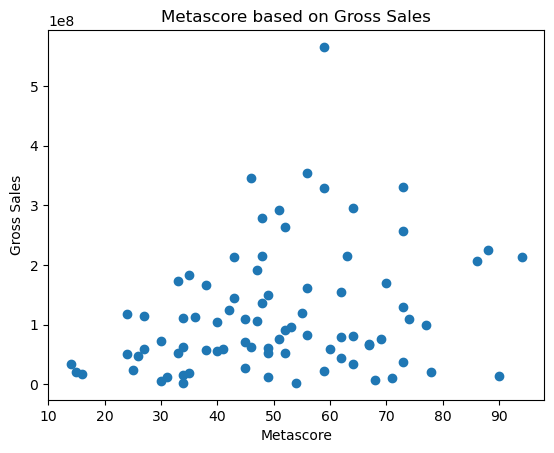

In [69]:
from matplotlib import pyplot 
pyplot.title('Metascore based on Gross Sales')
pyplot.xlabel('Metascore')
pyplot.ylabel('Gross Sales')
pyplot.scatter(unified_view['score'], unified_view['gross_sales'])
pyplot.show()

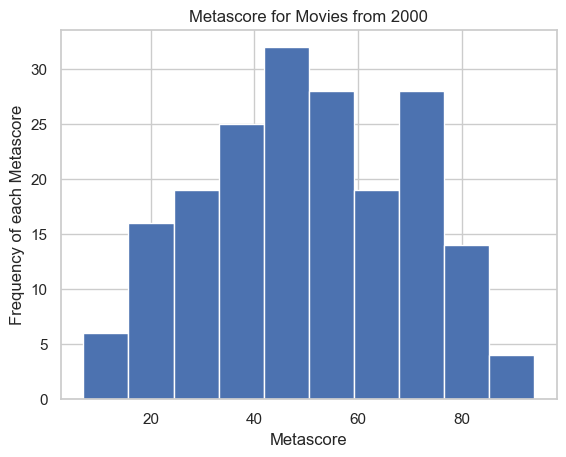

In [91]:
import numpy
pyplot.title('Metascore for Movies from 2000')
pyplot.xlabel('Metascore')
pyplot.ylabel('Frequency of each Metascore')
pyplot.hist(unified_view['score'], bins=10)
pyplot.show()

After plotting our data, we can see the relationship between a movie's metascore and gross sales in our scatter plot above. 
Returning to our question of whether a higher gross sales produces a higher metascore, it looks as though gross sales and metascore don't have much of an influence on each other. This is due to the fact that most of the scores for the movies during the year 2000 all hover around the lower gross sales amount even as the metascore got higher. We can also see that the movie with the highest gross sales produced a more average metascore so it seems as though these two factors are independent from each other. Due to this, we can conclude that a movie with a higher gross sales would not necessarily produce a higher metascore. 

I would like to cite Evdokia Samitova, who really helped me figure out how to convert the gross sales data into useful numeric data that can be used to calculate our regression model. 